280


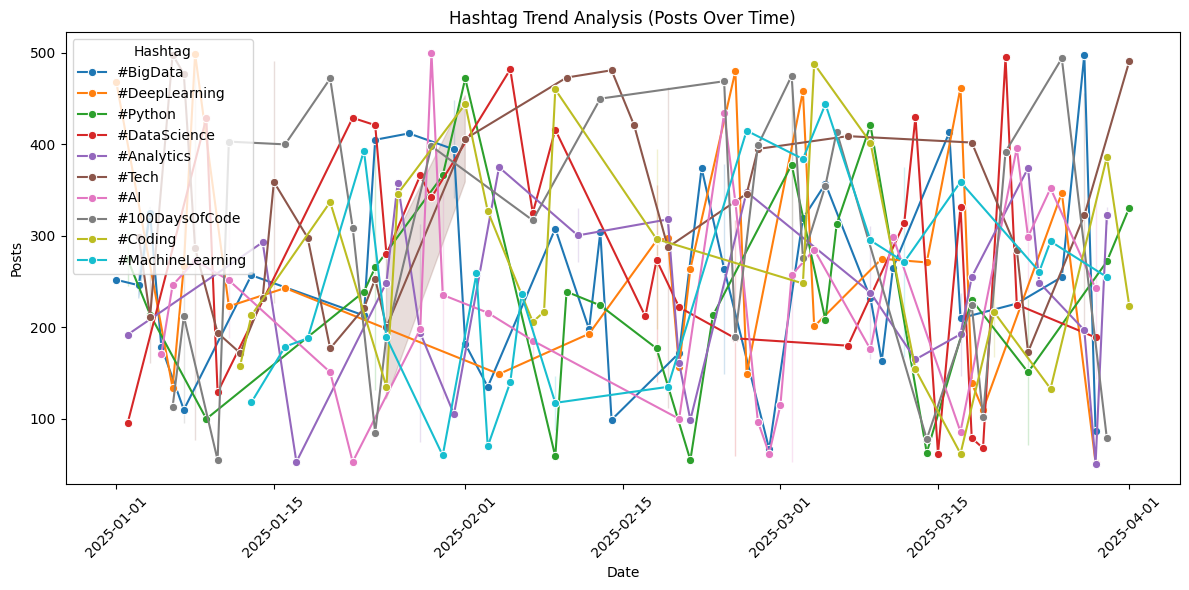

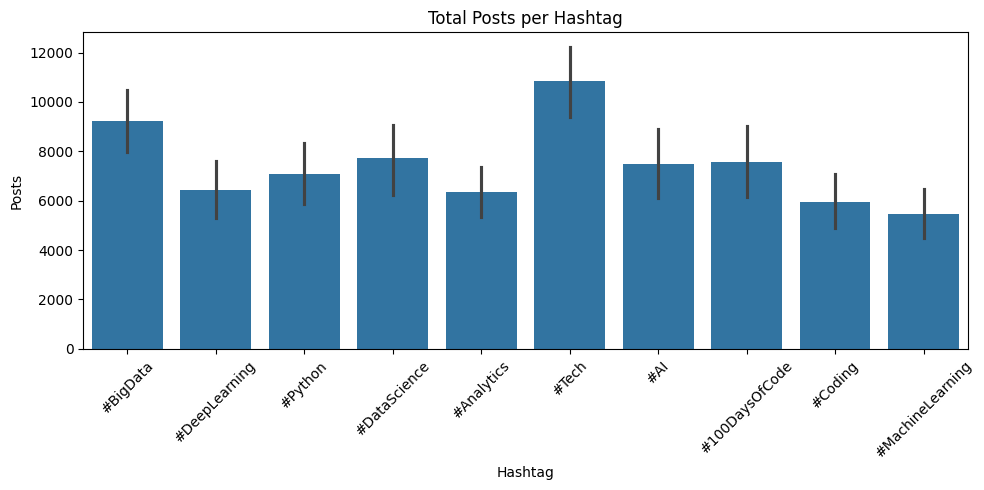

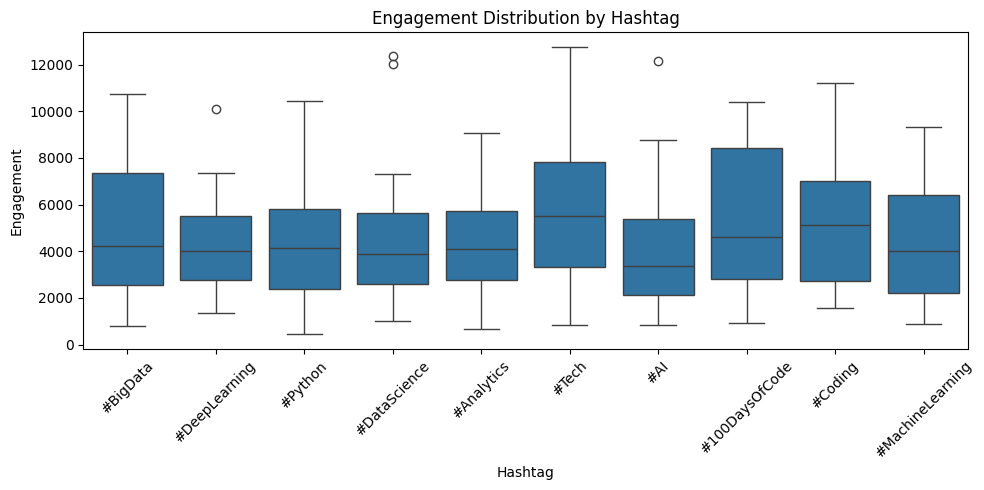

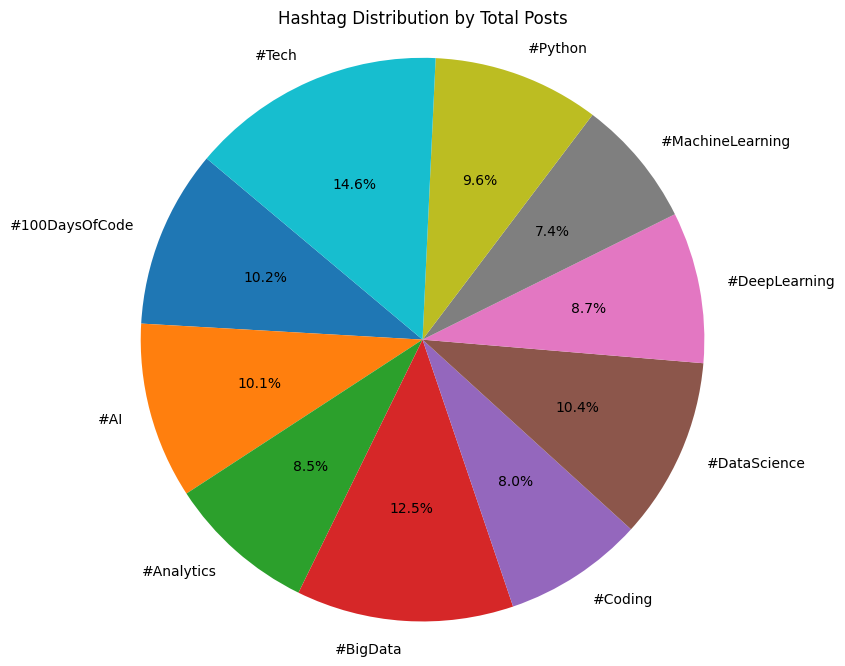

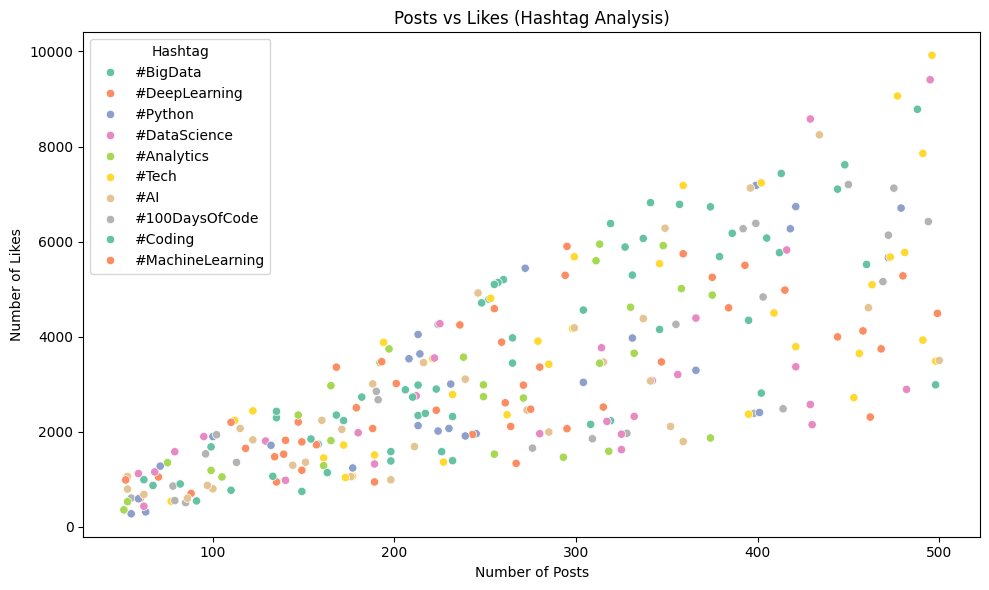

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\Dell\OneDrive\Desktop\Bigdata\hashtag_trends.csv")
print(len(df))
# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort data
df = df.sort_values('Date')
hashtag_counts = df.groupby("Hashtag")["Posts"].sum()
# Plot 1: Posts over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Date", y="Posts", hue="Hashtag", marker="o")
plt.title("Hashtag Trend Analysis (Posts Over Time)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Plot 2: Total posts per hashtag
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Hashtag", y="Posts", estimator=sum)
plt.title("Total Posts per Hashtag")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Plot 3: Engagement comparison
df['Engagement'] = df['Likes'] + df['Retweets']

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Hashtag", y="Engagement")
plt.title("Engagement Distribution by Hashtag")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    hashtag_counts,
    labels=hashtag_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Hashtag Distribution by Total Posts")
plt.axis('equal')  # Equal aspect ratio for perfect circle
plt.show()

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Posts",
    y="Likes",
    hue="Hashtag",
    palette="Set2"
)

plt.title("Posts vs Likes (Hashtag Analysis)")
plt.xlabel("Number of Posts")
plt.ylabel("Number of Likes")
plt.legend(title="Hashtag")
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
from collections import defaultdict

# =========================
# LOAD DATASET
# =========================
df = pd.read_csv(r"C:\Users\Dell\OneDrive\Desktop\Bigdata\hashtag_trends.csv")

print("Dataset Loaded:", df.shape)


# =========================================================
# 1️⃣ MAPREDUCE - TOTAL POSTS PER HASHTAG
# =========================================================

# MAP PHASE
mapped_posts = []

for _, row in df.iterrows():
    hashtag = row["Hashtag"]
    posts = row["Posts"]
    mapped_posts.append((hashtag, posts))

print("\nMapped Posts Sample:", mapped_posts[:5])


# REDUCE PHASE
reduced_posts = defaultdict(int)

for key, value in mapped_posts:
    reduced_posts[key] += value

print("\n===== TOTAL POSTS PER HASHTAG =====")
for k, v in reduced_posts.items():
    print(k, "->", v)


# Convert to DataFrame
posts_df = pd.DataFrame(list(reduced_posts.items()),
                        columns=["Hashtag", "Total_Posts"])


# =========================================================
# 2️⃣ MAPREDUCE - ENGAGEMENT PER HASHTAG
# =========================================================

# MAP PHASE
mapped_engagement = []

for _, row in df.iterrows():
    hashtag = row["Hashtag"]
    engagement = row["Likes"] + row["Retweets"]
    mapped_engagement.append((hashtag, engagement))

print("\nMapped Engagement Sample:", mapped_engagement[:5])


# REDUCE PHASE
reduced_engagement = defaultdict(int)

for key, value in mapped_engagement:
    reduced_engagement[key] += value

print("\n===== ENGAGEMENT PER HASHTAG =====")
for k, v in reduced_engagement.items():
    print(k, "->", v)


# Convert to DataFrame
engagement_df = pd.DataFrame(list(reduced_engagement.items()),
                             columns=["Hashtag", "Engagement"])


# =========================================================
# 3️⃣ MAPREDUCE - DAILY TREND (DATE + HASHTAG)
# =========================================================

# MAP PHASE
mapped_trend = []

for _, row in df.iterrows():
    key = (row["Date"], row["Hashtag"])
    value = row["Posts"]
    mapped_trend.append((key, value))

print("\nTrend Mapped Sample:", mapped_trend[:5])


# REDUCE PHASE
reduced_trend = defaultdict(int)

for key, value in mapped_trend:
    reduced_trend[key] += value

print("\n===== DAILY TREND OUTPUT =====")
for k, v in list(reduced_trend.items())[:10]:
    print(k, "->", v)


# Convert to DataFrame
trend_df = pd.DataFrame(
    [(k[0], k[1], v) for k, v in reduced_trend.items()],
    columns=["Date", "Hashtag", "Total_Posts"]
)


# =========================================================
# FINAL OUTPUT TABLES
# =========================================================

print("\n\n===== FINAL TABLES READY =====")

print("\nPosts per Hashtag:")
print(posts_df)

print("\nEngagement per Hashtag:")
print(engagement_df)

print("\nTrend Data Sample:")
print(trend_df.head())

Dataset Loaded: (280, 5)

Mapped Posts Sample: [('#100DaysOfCode', 276), ('#Python', 421), ('#Analytics', 293), ('#DeepLearning', 280), ('#AI', 396)]

===== TOTAL POSTS PER HASHTAG =====
#100DaysOfCode -> 7564
#Python -> 7089
#Analytics -> 6337
#DeepLearning -> 6431
#AI -> 7489
#Tech -> 10844
#MachineLearning -> 5452
#DataScience -> 7719
#Coding -> 5965
#BigData -> 9237

Mapped Engagement Sample: [('#100DaysOfCode', 2760), ('#Python', 8841), ('#Analytics', 2637), ('#DeepLearning', 5600), ('#AI', 7920)]

===== ENGAGEMENT PER HASHTAG =====
#100DaysOfCode -> 137232
#Python -> 123654
#Analytics -> 118325
#DeepLearning -> 102832
#AI -> 131167
#Tech -> 199131
#MachineLearning -> 101745
#DataScience -> 124124
#Coding -> 115827
#BigData -> 178544

Trend Mapped Sample: [(('2025-03-03', '#100DaysOfCode'), 276), (('2025-03-09', '#Python'), 421), (('2025-01-14', '#Analytics'), 293), (('2025-02-19', '#DeepLearning'), 280), (('2025-03-22', '#AI'), 396)]

===== DAILY TREND OUTPUT =====
('2025-03-03',